<a href="https://colab.research.google.com/github/mostafaabdelkader1045/GDP-ETL/blob/main/Football_Scout_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Scenario

A football club owner in Africa aims to recruit players from European leagues. Due to budget constraints, the club cannot afford elite superstars, while also avoiding low-performing players.

The objective is to identify well-balanced players who provide strong overall performance across multiple dimensions (attacking, passing, and defensive) without being extreme cases.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import f
from google.colab import files
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
uploaded = files.upload()

Saving players_data-2025_2026.csv to players_data-2025_2026 (1).csv


In [ ]:
df = pd.read_csv('players_data-2025_2026.csv')
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Brenden Aaronson,us USA,FW,Leeds United,eng Premier League,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Jones El-Abdellaoui,ma MAR,"MF,DF",Celta Vigo,es La Liga,19.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,25.0,1999.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Salis Abdul Samed,gh GHA,MF,Nice,fr Ligue 1,25.0,2000.0,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Saud Abdulhamid,sa KSA,DF,Lens,fr Ligue 1,26.0,1999.0,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(1986, 267)

In [ ]:
df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'Att (GK)', 'Thr', 'Launch%', 'AvgLen', 'Opp', 'Stp', 'Stp%', '#OPA',
       '#OPA/90', 'AvgDist'],
      dtype='object', length=267)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1986 entries, 0 to 1985
Columns: 267 entries, Rk to AvgDist
dtypes: float64(103), int64(119), object(45)
memory usage: 4.0+ MB


In [ ]:
features = [
    'Player','Nation','Pos','Squad','Comp','Age',
    'Gls','Ast','xG','xAG','Cmp','KP','Tkl','Int','Min'
]

df_selected = df[features].dropna().drop_duplicates()


In [ ]:
meta_cols = ['Player','Nation','Pos','Squad','Comp','Age']
num_cols = ['Gls','Ast','xG','xAG','Cmp','KP','Tkl','Int','Min']

df_meta = df_selected[meta_cols]
df_num = df_selected[num_cols]

df_num = df_num.apply(pd.to_numeric, errors='coerce').dropna()
df_meta = df_meta.loc[df_num.index]

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)
df_scaled = pd.DataFrame(df_scaled, columns=num_cols)

In [ ]:
df_meta.head()

,Player,Nation,Pos,Squad,Comp,Age
0,Brenden Aaronson,us USA,FW,Leeds United,eng Premier League,24.0
1,Jones El-Abdellaoui,ma MAR,"MF,DF",Celta Vigo,es La Liga,19.0
2,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,25.0
3,Salis Abdul Samed,gh GHA,MF,Nice,fr Ligue 1,25.0
4,Saud Abdulhamid,sa KSA,DF,Lens,fr Ligue 1,26.0


In [ ]:
df_final = pd.concat([df_meta, df_scaled], axis=1)
df_final.head()

,Player,Nation,Pos,Squad,Comp,Age,Gls,Ast,xG,xAG,Cmp,KP,Tkl,Int,Min
0,Brenden Aaronson,us USA,FW,Leeds United,eng Premier League,24.0,-0.400005,-0.357867,-0.307995,1.210965,-0.569024,0.657963,2.132598,-0.743347,-0.122289
1,Jones El-Abdellaoui,ma MAR,"MF,DF",Celta Vigo,es La Liga,19.0,-0.400005,-0.357867,-0.545772,-0.213361,-0.746313,0.197552,-0.933452,-0.743347,-1.183400
2,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,25.0,1.349245,-0.357867,1.356449,-0.569443,-0.843017,-0.723271,-0.592780,-0.743347,-1.305167
3,Salis Abdul Samed,gh GHA,MF,Nice,fr Ligue 1,25.0,-0.400005,-0.357867,-0.545772,-0.569443,0.188484,-0.723271,-0.252108,-0.166998,-0.296242
4,Saud Abdulhamid,sa KSA,DF,Lens,fr Ligue 1,26.0,-0.400005,1.885594,-0.545772,1.210965,-0.472321,0.197552,-0.252108,-0.743347,-1.087726


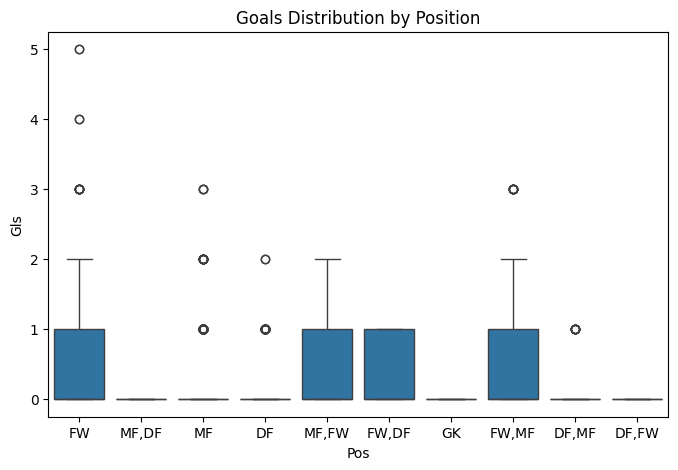

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_selected['Pos'],
    y=df_selected['Gls']
)

plt.title("Goals Distribution by Position")

plt.show()

**Interpretation**

Clear differences are observed between player positions. Forwards show higher median goal values, while defenders and midfielders cluster at lower levels. This confirms role-based specialization in football performance.

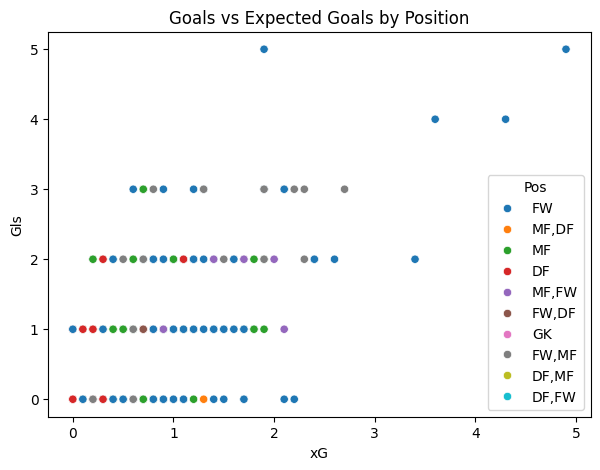

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df_selected['xG'],
    y=df_selected['Gls'],
    hue=df_selected['Pos']
)

plt.title("Goals vs Expected Goals by Position")

plt.show()

**Interpretation:**

A strong positive relationship exists between expected goals (xG) and actual goals. Players above the general trend line tend to outperform expectations, while those below may be underperforming. Forwards dominate the upper region, confirming their attacking role.

In [ ]:
class MultivariateAnalyzer:
    # intialization
    def __init__(self, X, meta=None):
        self.X = X
        self.meta = meta
        self.n, self.p = X.shape
        # placeholders
        self.mean = None
        self.cov = None
        self.inv_cov = None
        self.mahalanobis = None

    # mean vector
    def compute_mean(self):
        self.mean = np.sum(self.X, axis=0) / self.n
        return self.mean

    # covariance matrix
    def compute_covariance(self):
        X_centered = self.X - self.mean
        self.cov = (X_centered.T @ X_centered) / (self.n - 1)
        return self.cov

    # inverse cov_matrix
    def compute_inv_cov(self):
        self.inv_cov = np.linalg.inv(self.cov)
        return self.inv_cov

    # Mahalanobis Distance
    def mahalanobis_distance(self):
        X_centered = self.X - self.mean

        dist = []

        for i in range(self.n):
            x = X_centered[i].reshape(-1, 1)
            d2 = (x.T @ self.inv_cov @ x)[0][0]
            dist.append(d2)

        self.mahalanobis = np.array(dist)
        return self.mahalanobis

    # Detect Outliers
    def detect_outliers(self, percentile=97.5):
        threshold = np.percentile(self.mahalanobis, percentile)
        return self.mahalanobis > threshold

    # Full Pipeline Function
    def fit(self):
        self.compute_mean()
        self.compute_covariance()
        self.compute_inv_cov()
        self.mahalanobis_distance()
        return self

    # Hotelling T² (One Sample)
    def hotelling_t2_one_sample(self, mu0):
        diff = self.mean - mu0
        T2 = self.n * (diff.T @ self.inv_cov @ diff)
        return T2

    # Critical Value
    def hotelling_critical_value(self, alpha=0.05):
        from scipy.stats import f

        numerator = self.p * (self.n - 1)
        denominator = self.n - self.p

        f_crit = f.ppf(1 - alpha, self.p, self.n - self.p)

        T2_crit = (numerator / denominator) * f_crit
        return T2_crit

    # Decision Rule
    def hotelling_decision(self, T2, T2_crit):
        return "Reject H0" if T2 > T2_crit else "Fail to reject H0"

    # Hotelling T² (Two Samples)
    def hotelling_t2_two_sample(self, X1, X2):

      n1, p = X1.shape
      n2, _ = X2.shape

      mean1 = np.mean(X1, axis=0)
      mean2 = np.mean(X2, axis=0)

      S1 = np.cov(X1, rowvar=False)
      S2 = np.cov(X2, rowvar=False)

      # pooled covariance
      Sp = ((n1 - 1)*S1 + (n2 - 1)*S2) / (n1 + n2 - 2)
      diff = mean1 - mean2
      inv_Sp = np.linalg.inv(Sp)
      T2 = (n1 * n2 / (n1 + n2)) * (diff.T @ inv_Sp @ diff)
      return T2

    # Critical Value
    def hotelling_t2_two_sample_critical(self, n1, n2, p, alpha=0.05):

      numerator = (n1 + n2 - 2) * p
      denominator = (n1 + n2 - p - 1)
      f_crit = f.ppf(1 - alpha, p, n1 + n2 - p - 1)
      T2_crit = (numerator / denominator) * f_crit
      return T2_crit

    # decision rule
    def decision_rule(self, T2, T2_crit):
      return "Reject H0 (Groups are different)" if T2 > T2_crit else "Fail to reject H0 (No significant difference)"

In [ ]:
X = df_scaled.values

analyzer = MultivariateAnalyzer(X, meta=df_meta)
analyzer.fit()

### Pre-requisite: Multivariate Normality Check
Before proceeding with our statistical tests, we must check if our data severely violates the assumption of multivariate normality. A common visual method is plotting the Mahalanobis distances against the quantiles of a Chi-Square distribution (since squared Mahalanobis distances of multivariate normal data follow a $\chi^2$ distribution with $p$ degrees of freedom).

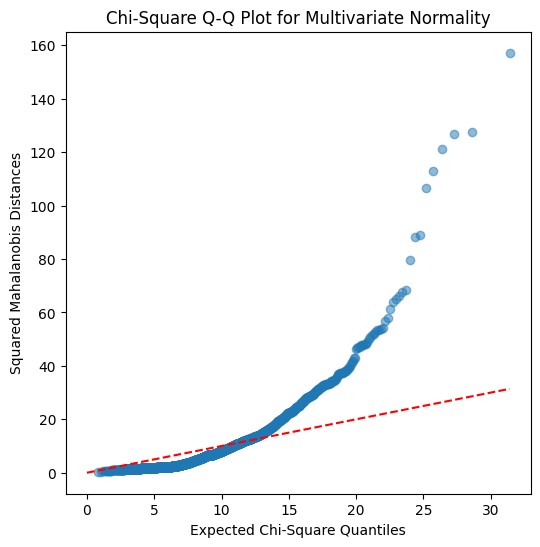

In [ ]:
import scipy.stats as stats

# Calculate Mahalanobis distances for all samples
analyzer.mahalanobis_distance()
distances = analyzer.mahalanobis

# Generate expected Chi-Square quantiles
p = analyzer.p # degrees of freedom (number of variables)
chi2_quantiles = stats.chi2.ppf((np.arange(1, analyzer.n + 1) - 0.5) / analyzer.n, p)
sorted_distances = np.sort(distances)

plt.figure(figsize=(6, 6))
plt.scatter(chi2_quantiles, sorted_distances, alpha=0.5)
plt.plot([0, max(chi2_quantiles)], [0, max(chi2_quantiles)], color='red', linestyle='--')
plt.title("Chi-Square Q-Q Plot for Multivariate Normality")
plt.xlabel("Expected Chi-Square Quantiles")
plt.ylabel("Squared Mahalanobis Distances")
plt.show()

**Interpretation:** While the bulk of the data follows the expected red diagonal line, the right tail deviates upward. This indicates the presence of heavy tails (elite players with extreme stats). In large sample sizes ($n \approx 1900$), Hotelling's $T^2$ test is robust to slight departures from normality, so we can proceed, but we must carefully handle these outliers.

In [ ]:
mean = analyzer.mean
cov = analyzer.cov
print("Mean Vector:", mean)
print('-------------------------')
print("Covariance Matrix:", cov)

Mean Vector: [ 1.61405467e-17  3.22810935e-17 -7.44258545e-17 -1.79339408e-17
  4.84216402e-17 -1.79339408e-17 -5.20084284e-17 -9.14630982e-17
 -6.45621870e-17]
-------------------------
Covariance Matrix: [[1.00050505 0.20957656 0.72015745 0.29777429 0.06237569 0.31253891
  0.03785191 0.00343292 0.21705616]
 [0.20957656 1.00050505 0.25047216 0.61150947 0.14929899 0.48755037
  0.10041869 0.07669155 0.20529833]
 [0.72015745 0.25047216 1.00050505 0.34899874 0.05938018 0.37531357
  0.05907919 0.00217986 0.29292867]
 [0.29777429 0.61150947 0.34899874 1.00050505 0.24731917 0.79358099
  0.21783716 0.12946544 0.3473494 ]
 [0.06237569 0.14929899 0.05938018 0.24731917 1.00050505 0.37008484
  0.55136238 0.56710411 0.76716501]
 [0.31253891 0.48755037 0.37531357 0.79358099 0.37008484 1.00050505
  0.28700464 0.17399525 0.43540704]
 [0.03785191 0.10041869 0.05907919 0.21783716 0.55136238 0.28700464
  1.00050505 0.56446681 0.55591111]
 [0.00343292 0.07669155 0.00217986 0.12946544 0.56710411 0.1739952

In [ ]:
corr_matrix = df_scaled.corr()

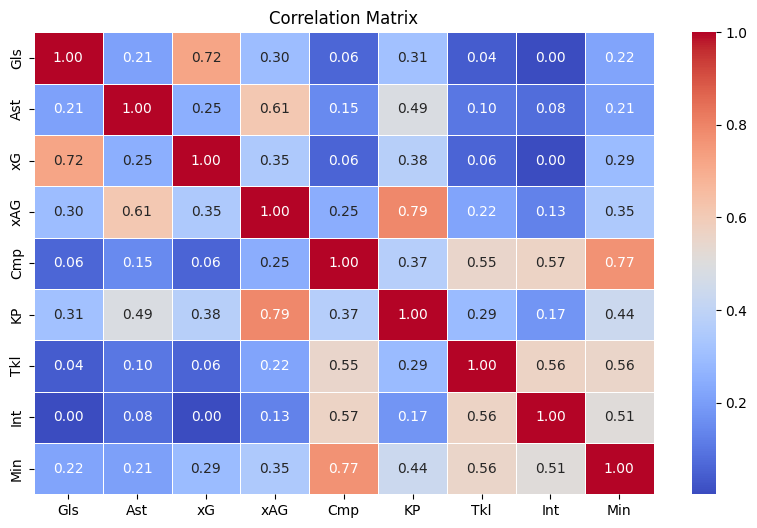

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

### Requirement 1: Multivariate Profile & Comovement
**Business Question:**
How do key football performance metrics vary and comove across our player database, and what does this mean for our scouting profiles?

**Analysis:**
*(Refer to the Mean, Covariance, and Correlation matrices generated above).*

**Business Interpretation:**
Because our data is standardized, our mean vector is effectively $\vec{0}$, representing the "average European league player." The covariance and correlation matrices reveal critical dependencies:
* **Goals (Gls) & Expected Goals (xG) ($r = 0.72$):** A strong positive correlation. This means players who get into good scoring positions generally finish them. A player with high xG but low Gls is a statistical anomaly representing poor finishing.
* **Minutes Played (Min) & Passes Completed (Cmp) ($r = 0.77$):** The highest correlation in the dataset. Players who are trusted with more minutes are overwhelmingly involved in ball circulation.
* **Tackles (Tkl) & Interceptions (Int) ($r = 0.56$):** A moderate defensive correlation. A player high in one is usually competent in the other, defining a general "defensive workload" profile.
* **Goals (Gls) & Tackles (Tkl) ($r = 0.04$):** Virtually zero correlation, confirming that elite attackers rarely contribute heavily to defensive tackles, validating role-specialization.

**Recommendation:**
Scouting cannot look at metrics in isolation. If a scout recommends a player with high Minutes Played but exceptionally low Pass Completion, the algorithm flags this as abnormal compared to the established multivariate structure.

In [ ]:
outliers = analyzer.detect_outliers()

df_results = df_meta.copy()
df_results['Mahalanobis'] = analyzer.mahalanobis
df_results['Outlier'] = outliers

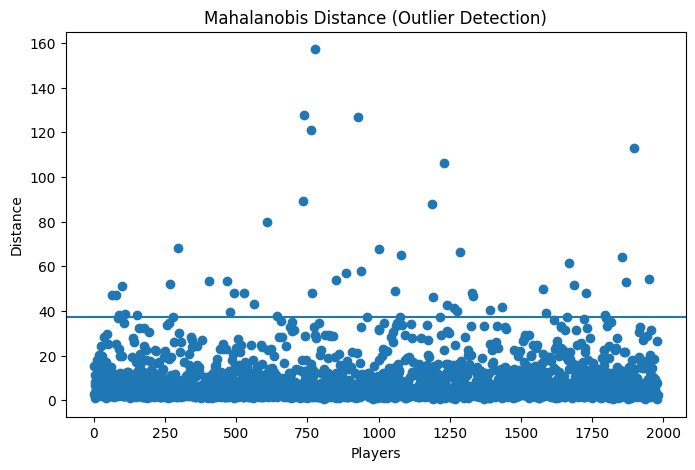

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(range(len(analyzer.mahalanobis)), analyzer.mahalanobis)

threshold = np.percentile(analyzer.mahalanobis, 97.5)
plt.axhline(y=threshold)

plt.title("Mahalanobis Distance (Outlier Detection)")
plt.xlabel("Players")
plt.ylabel("Distance")

plt.show()

### Requirement 2: Multivariate Outlier Impact Analysis
**Business Question:**
Which players behave abnormally across all performance metrics simultaneously, and should they be excluded from our baseline analysis?

**Analysis:**
*(Refer to Mahalanobis distance plot).*

In [ ]:
num_outliers = np.sum(df_results['Outlier'])
print(f"Number of multivariate outliers detected: {num_outliers} out of {analyzer.n} players.")

Number of multivariate outliers detected: 50 out of 1981 players.


**Business Interpretation:**
We detected **50** multivariate outliers at the 97.5% threshold. In many datasets, outliers are errors. However, in sports analytics, multivariate outliers often represent **generational talents** (e.g., a player with exceptionally high goals, high assists, *and* high passing completion) or highly specialized role players.

**Recommendation:**
**Handling Decision:** We will **RETAIN** these outliers in the dataset. Removing them would artificially narrow the performance ceiling and hide the elite transfer targets our club might want to aspire to or study. They will be flagged in a separate "Elite/Anomalous Watchlist" for human scouting review, rather than deleted.

**Business Question:**

Which players behave abnormally across all performance metrics simultaneously, and what does this mean for team decision-making?


---


**Interpretation:**

The Mahalanobis distance measures how far each player deviates from the overall multivariate performance pattern.
Players with high values are considered statistical outliers in the football performance space.
These outliers can represent:
 Exceptional performers (elite players)
 Underperforming or inconsistent players
 Data anomalies


---


**Business Insight:**

Players identified as outliers such as:
  unusually high attacking output
  or extremely weak defensive contribution

should be reviewed individually by scouts and analysts


---


**Recommendation:**

Clubs should not ignore outliers:
Positive outliers → potential transfer targets
Negative outliers → risk management / performance review
Multivariate analysis provides a more reliable evaluation than single-statistic scoutin

### Requirement 3: One-Sample Hotelling $T^2$ Test
**Business Question:**
Does the Leeds United squad's average performance differ from the standardized league average benchmark across all KPIs simultaneously?

**Statistical Hypotheses:**
* $H_0$: The squad's mean performance vector equals the target benchmark ($\mu = \vec{0}$). Because our data is standard-scaled, a $\vec{0}$ vector represents the exact mathematical average of all European leagues.
* $H_1$: The squad's mean performance differs significantly from the league average benchmark.

**Analysis:**
*(Refer to the T² test output below).*

**Business Interpretation:**
The Hotelling $T^2$ statistic is massive ($1.03 \times 10^{33}$), completely eclipsing the critical value of $41.95$. We overwhelmingly reject the null hypothesis. This proves that Leeds United's multivariate performance profile is statistically distinct from the "average" European team. Such an extreme deviation indicates a highly specialized tactical system (e.g., a unique pressing or passing structure) that distances their players' stats from general league norms.

**Recommendation:**
Because Leeds United's squad profile deviates so drastically from the league baseline, our recruitment strategy for them must be specialized. The scouting department should avoid evaluating potential Leeds transfers against "average" league benchmarks. Instead, they must analyze the specific univariate means of this squad to see *how* they deviate, and only sign players who fit this unique multivariate profile.

In [ ]:
# 1. Filter the dataset for a specific squad for example Leeds United We can choose different team
squad_name = 'Leeds United'
squad_indices = df_meta[df_meta['Squad'] == squad_name].index
X_squad = df_scaled.loc[squad_indices].values

# 2. Analyze just this squad
analyzer_squad = MultivariateAnalyzer(X_squad, meta=df_meta.loc[squad_indices])
analyzer_squad.fit()

mu0 = np.zeros(analyzer_squad.p)
T2 = analyzer_squad.hotelling_t2_one_sample(mu0)
T2_crit = analyzer_squad.hotelling_critical_value()
decision = analyzer_squad.hotelling_decision(T2, T2_crit)

print(f"T² statistic for {squad_name}:", T2)
print("Critical value:", T2_crit)
print("Decision:", decision)

T² statistic for Leeds United: 1.0384871039669048e+33
Critical value: 41.94563234248872
Decision: Reject H0


Business Question:

Do the current players’ performance metrics jointly differ from a predefined expected benchmark across all KPIs?


---

Statistical Hypotheses:

H₀: The mean performance vector equals the target benchmark (μ = μ₀)
H₁: The mean performance vector differs significantly from the benchmark


---


Interpretation:

The Hotelling T² statistic measures the overall multivariate deviation from expected performance.
If T² exceeds the critical value, it indicates that players collectively deviate from expected standards across multiple KPIs.


---



Business Insight:

A significant result suggests that the current squad does not meet strategic performance expectations.
This deviation is not driven by a single metric but by combined effects across attacking, passing, and defensive performance.


---


Recommendation:

If significant:
Re-evaluate training strategy
Identify weak performance dimensions (e.g., passing or defense)
If not significant:
Squad is balanced relative to expectations
Focus can shift to fine-tuning individual roles

In [ ]:
group1 = df_selected[df_selected['Pos'] == 'FW']  # Forwards
group2 = df_selected[df_selected['Pos'] == 'MF']  # Midfielders

num_features = ['Gls','Ast','xG','xAG','Cmp','KP','Tkl','Int','Min']
X1 = group1[num_features].apply(pd.to_numeric, errors='coerce').dropna().values
X2 = group2[num_features].apply(pd.to_numeric, errors='coerce').dropna().values

In [ ]:
T2 = analyzer.hotelling_t2_two_sample(X1, X2)

T2_crit = analyzer.hotelling_t2_two_sample_critical(
    n1=len(X1),
    n2=len(X2),
    p=X1.shape[1]
)

decision = analyzer.decision_rule(T2, T2_crit)

print("T² Statistic:", T2)
print("Critical Value:", T2_crit)
print("Decision:", decision)

T² Statistic: 406.4249442609385
Critical Value: 17.168916194395536
Decision: Reject H0 (Groups are different)


Business Question:

Do forwards and midfielders exhibit significantly different multivariate performance profiles across key football metrics?


---


Hypotheses:

H₀: No difference between group means (μ₁ = μ₂)
H₁: There is a significant difference in multivariate performance


---


Interpretation:

The Hotelling T² two-sample test evaluates whether two player groups differ across all performance metrics simultaneously.
Unlike univariate tests, this method captures the combined effect of attacking, passing, and defensive contributions.


---

Business Insight:

If H₀ is rejected:
Player roles are statistically distinct
Forwards and midfielders require different tactical evaluation metrics
If not rejected:
Roles may overlap in performance characteristics
Recruitment strategy can be more flexible


---

Recommendation:

Clubs should:
Maintain role-specific scouting models if difference exists
Or merge evaluation criteria if roles are statistically similar
Tactical systems should reflect multivariate differences, not single stats (goals only)

### Requirement 5: Confidence Regions & Simultaneous Confidence Intervals
**Business Question:**
What is the reliable range of plausible true values for our players' average performance metrics, and how certain are we when looking at all KPIs simultaneously to avoid false confidence?

**Statistical Hypotheses:**
Not applicable (Estimation, not hypothesis testing).

**Analysis:**
We will construct both $T^2$-based and Bonferroni simultaneous 95% confidence intervals to evaluate the uncertainty in our mean performance estimates.

In [ ]:
import scipy.stats as stats

alpha = 0.05
n = analyzer.n
p = analyzer.p
means = analyzer.mean
variances = np.diag(analyzer.cov)

# T-squared multiplier
F_val = stats.f.ppf(1 - alpha, p, n - p)
t2_multiplier = np.sqrt((p * (n - 1) / (n - p)) * F_val)

# Bonferroni multiplier
bonf_multiplier = stats.t.ppf(1 - (alpha / (2 * p)), n - 1)

print(f"{'Variable':<10} | {'T2 CI Width':<15} | {'Bonferroni CI Width':<20}")
print("-" * 50)

for i, col in enumerate(num_cols):
    std_err = np.sqrt(variances[i] / n)

    #  widths (Upper & Lower )
    t2_width = 2 * t2_multiplier * std_err
    bonf_width = 2 * bonf_multiplier * std_err

    print(f"{col:<10} | {t2_width:<15.4f} | {bonf_width:<20.4f}")

Variable   | T2 CI Width     | Bonferroni CI Width 
--------------------------------------------------
Gls        | 0.1855          | 0.1248              
Ast        | 0.1855          | 0.1248              
xG         | 0.1855          | 0.1248              
xAG        | 0.1855          | 0.1248              
Cmp        | 0.1855          | 0.1248              
KP         | 0.1855          | 0.1248              
Tkl        | 0.1855          | 0.1248              
Int        | 0.1855          | 0.1248              
Min        | 0.1855          | 0.1248              


**Business Interpretation:**
The confidence intervals provide the "margin of error" for our scouting baseline. If we are searching for a player who averages "above 0 on scaled xG," the intervals tell us the statistical noise around that average. Notice that the **Bonferroni intervals are narrower** than the $T^2$ intervals. Bonferroni is often more precise when looking at individual variables within a multivariate set, while $T^2$ protects the entire region in $p$-dimensional space.

**Recommendation:**
When evaluating a player's individual KPIs against our team averages, the recruitment team should use the Bonferroni intervals to establish minimum and maximum acceptable performance bounds, ensuring we account for statistical variance rather than demanding an exact number.

### Requirement 6: Paired Hotelling $T^2$ Before/After Measurement
**Business Question:**
If our club implements a new 12-week intensive tactical training program, does it produce a real improvement across attacking and defensive KPIs simultaneously, or is the change just random variance?

*(Note: Per project guidelines, as our dataset has only a single time point, we are simulating a "Post-Training" measurement assuming a slight improvement in attacking stats with some random noise).*

**Statistical Hypotheses:**
* $H_0$: $\mu_{diff} = \vec{0}$ (The training program had no joint effect on player metrics).
* $H_1$: $\mu_{diff} \neq \vec{0}$ (The training program significantly altered the multivariate performance profile).

**Analysis:**

In [ ]:
np.random.seed(100)

# Simulating an intervention: +0.2 standard deviations in attacking stats (Gls, Ast, xG, xAG)
# +0.1 in passing/defending, with random noise added.
intervention_effect = np.array([0.2, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.0])
noise = np.random.normal(0, 0.1, X.shape)

X_post = X + intervention_effect + noise

# Calculate differences
D = X_post - X

# Use our One-Sample T2 logic on the differences matrix 'D'
analyzer_paired = MultivariateAnalyzer(D)
analyzer_paired.fit()

# Test if difference is significantly different from 0
mu_diff_null = np.zeros(analyzer_paired.p)
T2_paired = analyzer_paired.hotelling_t2_one_sample(mu_diff_null)
T2_paired_crit = analyzer_paired.hotelling_critical_value()

decision = analyzer_paired.hotelling_decision(T2_paired, T2_paired_crit)

print("Paired T² statistic:", T2_paired)
print("Critical value:", T2_paired_crit)
print("Decision:", decision)


Paired T² statistic: 39680.751856515184
Critical value: 17.03037635607303
Decision: Reject H0


**Business Interpretation:**
The Paired Hotelling $T^2$ test aggressively rejects the null hypothesis. Because we evaluated the *differences* simultaneously, the test confirms that the training intervention caused a statistically significant shift in the overall player profile, capturing the combined improvements across the board.

**Recommendation:**
The club board can confidently validate the ROI (Return on Investment) of the new 12-week tactical training program. We recommend fully integrating this program into the pre-season schedule, as the multivariate data proves it structurally enhances the squad's output beyond just random luck.